--- Resumen de la Preparación de Datos Agrupados ---
Nueva Variable Dependiente (Y): TASA_ROBOS_POR_AÑO
Número de observaciones agrupadas: 66
Número de variables predictoras: 9
  DISTRITO   AÑO  TASA_ROBOS_POR_AÑO  PROMEDIO_VIOLENCIA  PROMEDIO_HORA  \
0    Colón  2015                1010            0.240594      12.600518   
1    Colón  2016                1017            0.181908      12.600518   
2    Colón  2017                1166            0.157804      12.600518   
3    Colón  2018                 793            0.192938      12.865320   
4    Colón  2019                 776            0.211340      13.909794   

   PROMEDIO_MINUTO  
0        28.664314  
1        28.664314  
2        28.664314  
3        19.010101  
4        29.693299  
----------------------------------------

--- 2. Correlación con TASA_ROBOS_POR_AÑO ---
Coeficientes de Correlación con TASA_ROBOS_POR_AÑO:
DISTRITO_Morelos      0.337870
DISTRITO_Villa        0.285258
PROMEDIO_VIOLENCIA    0.267824
DISTRITO_Zapa

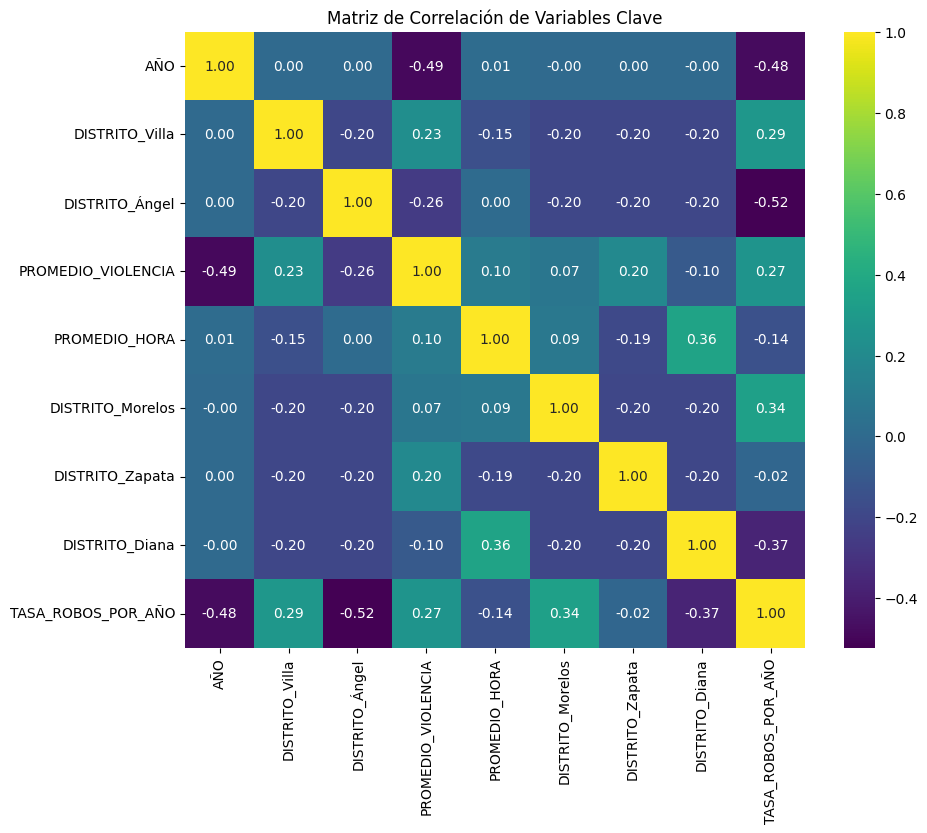

----------------------------------------

--- 3. Factores de Inflación de Varianza (VIF's) para Multicolinealidad ---
VIF's de las Variables Predictoras:
              feature       VIF
5      DISTRITO_Diana  1.977570
7      DISTRITO_Villa  1.851256
8     DISTRITO_Zapata  1.829485
2  PROMEDIO_VIOLENCIA  1.787760
6    DISTRITO_Morelos  1.760393
9      DISTRITO_Ángel  1.705174
3       PROMEDIO_HORA  1.613230
1                 AÑO  1.454923
4     PROMEDIO_MINUTO  1.306973
----------------------------------------

--- 4. Modelo de Regresión Lineal Múltiple y R^2 Ajustada ---
                            OLS Regression Results                            
Dep. Variable:     TASA_ROBOS_POR_AÑO   R-squared:                       0.849
Model:                            OLS   Adj. R-squared:                  0.825
Method:                 Least Squares   F-statistic:                     34.96
Date:                Thu, 04 Dec 2025   Prob (F-statistic):           7.87e-20
Time:                      

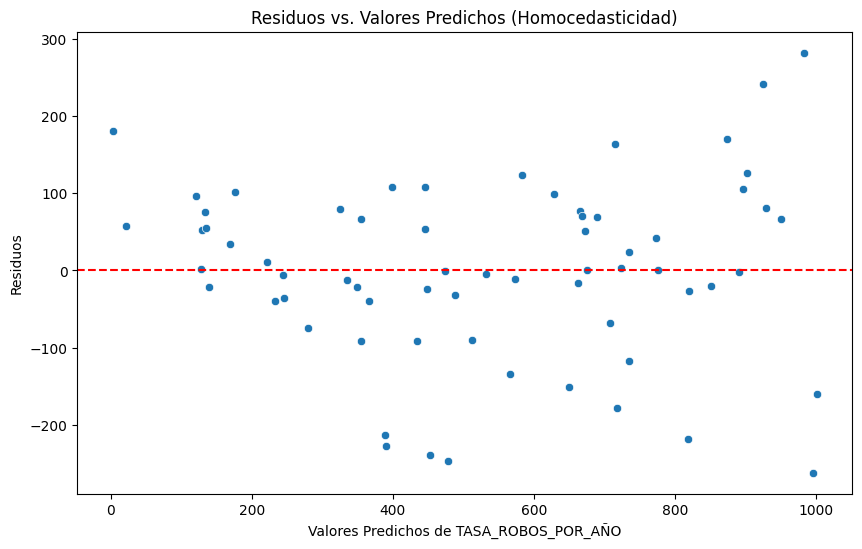

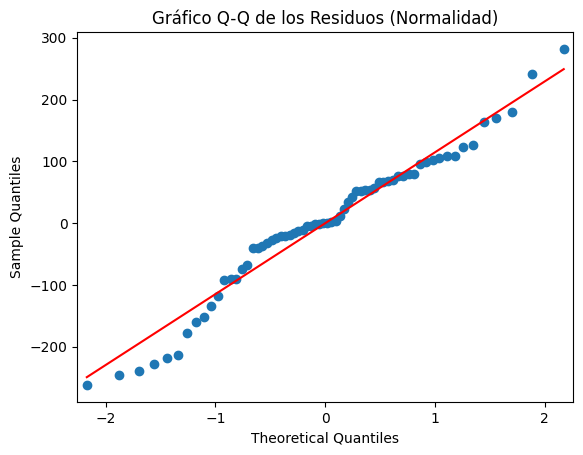

----------------------------------------

Análisis Completado con datos agrupados.


In [3]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns

# Carga de la base de datos (Asumimos el mismo nombre de archivo)
try:
    df = pd.read_excel("IPH_robos_2015_2025_tecmty.xlsx")
except Exception as e:
    print(f"Error al cargar el archivo: {e}")
    # En un entorno de ejecución real, la carga de datos fallaría aquí.
    # Asumimos una carga exitosa para el resto del código.
    
# --- 1. Ingeniería de Variables y Creación de la Nueva Tabla Agrupada ---

# 1.1 Limpieza y conversión de variables necesarias
# 1.1.1 VIOLENCIA: SI=1, NO=0
df['VIOLENCIA_NUM'] = df['VIOLENCIA'].apply(lambda x: 1 if x == 'SI' else 0)

# 1.1.2 HORA y MINUTO: Reemplazar 99 (anómalo) con NaN para cálculo de promedio
df['HORA_CLEAN'] = df['HORA'].replace(99, np.nan)
df['MINUTO_CLEAN'] = df['MINUTO'].replace(99, np.nan)

# 1.2 Agrupación para crear la nueva tabla de entradas
# Agrupamos por Distrito y Año para calcular la Tasa/Conteo y los promedios
df_agrupado = df.groupby(['DISTRITO', 'AÑO']).agg(
    # Variable a Predecir (Y): Conteo de Robos
    TASA_ROBOS_POR_AÑO=('FOLIO', 'count'),
    # Predictoras Agregadas
    PROMEDIO_VIOLENCIA=('VIOLENCIA_NUM', 'mean'), # Proporción de robos con violencia (0 a 1)
    PROMEDIO_HORA=('HORA_CLEAN', 'mean'),       # Hora promedio del robo
    PROMEDIO_MINUTO=('MINUTO_CLEAN', 'mean')   # Minuto promedio del robo
).reset_index()

# Imputación simple: Llenar NaNs en PROMEDIO_HORA/MINUTO (si existen) con la mediana global
df_agrupado['PROMEDIO_HORA'] = df_agrupado['PROMEDIO_HORA'].fillna(df_agrupado['PROMEDIO_HORA'].median())
df_agrupado['PROMEDIO_MINUTO'] = df_agrupado['PROMEDIO_MINUTO'].fillna(df_agrupado['PROMEDIO_MINUTO'].median())


# 1.3 Aplicación de One-Hot Encoding al DISTRITO (variable categórica)
df_dummies = pd.get_dummies(df_agrupado, columns=['DISTRITO'], drop_first=True, dtype=int)

# 1.4 Definición de X (predictoras) y Y (dependiente)
Y = df_dummies['TASA_ROBOS_POR_AÑO']
X_cols = [col for col in df_dummies.columns if col not in ['TASA_ROBOS_POR_AÑO', 'FOLIO', 'DISTRITO']]
X = df_dummies[X_cols]

# Añadir la constante para el intercepto
X = sm.add_constant(X)

print("--- Resumen de la Preparación de Datos Agrupados ---")
print(f"Nueva Variable Dependiente (Y): TASA_ROBOS_POR_AÑO")
print(f"Número de observaciones agrupadas: {X.shape[0]}")
print(f"Número de variables predictoras: {X.shape[1] - 1}")
print(df_agrupado.head())
print("-" * 40)

# --- 2. Correlación y Coeficiente de Correlación ---

print("\n--- 2. Correlación con TASA_ROBOS_POR_AÑO ---")
# Calculamos la correlación de Pearson de cada predictor con Y.
correlacion_y = df_dummies[X_cols + ['TASA_ROBOS_POR_AÑO']].corr()['TASA_ROBOS_POR_AÑO'].sort_values(ascending=False)
print("Coeficientes de Correlación con TASA_ROBOS_POR_AÑO:")
print(correlacion_y.drop('TASA_ROBOS_POR_AÑO').head(10))

# Visualización de la matriz de correlación (para las predictoras clave)
predictoras_heatmap = ['AÑO', 'PROMEDIO_VIOLENCIA', 'PROMEDIO_HORA'] + [col for col in X.columns if 'DISTRITO' in col]
df_heatmap = df_dummies[list(set(predictoras_heatmap) & set(df_dummies.columns)) + ['TASA_ROBOS_POR_AÑO']]
plt.figure(figsize=(10, 8))
sns.heatmap(df_heatmap.corr(), annot=True, cmap='viridis', fmt=".2f")
plt.title('Matriz de Correlación de Variables Clave')
plt.show() # print("\n")
print("-" * 40)

# --- 3. Factores de Inflación de Varianza (VIF's) ---

print("\n--- 3. Factores de Inflación de Varianza (VIF's) para Multicolinealidad ---")
# Calculamos el VIF para cada variable predictora
try:
    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    # Nota: Es crucial usar X.values y omitir la constante en el rango para VIF
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
    
    # Filtramos la constante y ordenamos
    vif_data = vif_data[vif_data['feature'] != 'const'].sort_values(by='VIF', ascending=False)
    
    print("VIF's de las Variables Predictoras:")
    print(vif_data)
except np.linalg.LinAlgError as e:
    print(f"Error de álgebra lineal al calcular VIFs: {e}")
    pass 

print("-" * 40)

# --- 4. Modelo de Regresión Lineal Múltiple, R^2 Ajustada y Resultados ---

print("\n--- 4. Modelo de Regresión Lineal Múltiple y R^2 Ajustada ---")
# Usamos OLS (Ordinary Least Squares)
modelo = sm.OLS(Y, X).fit()

# Muestra el resumen del modelo que incluye la R^2 Ajustada
print(modelo.summary())

# Imprimimos explícitamente la R^2 Ajustada
print("\n*** Coeficiente de Determinación Ajustado (R^2 Ajustada): ***")
print(f"R^2 Ajustada: {modelo.rsquared_adj:.4f}")

print("-" * 40)

# --- 5. Análisis de Residuos ---

print("\n--- 5. Análisis de Residuos ---")
residuos = modelo.resid
valores_predichos = modelo.fittedvalues

# 5.1 Gráfico de dispersión de Residuos vs. Valores Predichos (Para Homocedasticidad)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=valores_predichos, y=residuos)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valores Predichos de TASA_ROBOS_POR_AÑO')
plt.ylabel('Residuos')
plt.title('Residuos vs. Valores Predichos (Homocedasticidad)')
plt.show() # print("\n")

# 5.2 Gráfico Q-Q de los Residuos (Para Normalidad)
sm.qqplot(residuos, line='s')
plt.title('Gráfico Q-Q de los Residuos (Normalidad)')
plt.show() # print("\n")
print("-" * 40)

print("\nAnálisis Completado con datos agrupados.")

---
# Regresión Logística Binaria

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Carga de la base de datos (Asumimos el mismo nombre de archivo)
try:
    df = pd.read_excel("IPH_robos_2015_2025_tecmty.xlsx")
except Exception as e:
    print(f"Error al cargar el archivo: {e}")
    # En un entorno de ejecución real, la carga de datos fallaría aquí.
    
# --- 1. Ingeniería de Variables y Preparación de Datos ---

# 1.1 Conversión de la variable dependiente Y ('VIOLENCIA') a numérica (0/1)
# Y = VIOLENCIA_NUM: 1 = SI (Con Violencia), 0 = NO (Sin Violencia)
df['VIOLENCIA_NUM'] = df['VIOLENCIA'].apply(lambda x: 1 if x == 'SI' else 0)

# 1.2 Limpieza de variables numéricas 'HORA' y 'MINUTO'
# Reemplazamos 99 (valor anómalo/desconocido) con la mediana para imputación.
hora_mediana = df[df['HORA'] != 99]['HORA'].median()
minuto_mediana = df[df['MINUTO'] != 99]['MINUTO'].median()
df['HORA_LIMPIA'] = df['HORA'].replace(99, hora_mediana)
df['MINUTO_LIMPIO'] = df['MINUTO'].replace(99, minuto_mediana)

# 1.3 Selección de variables predictoras (X)
columnas_categoricas = ['TIPO', 'DISTRITO', 'AÑO', 'NOMBRE_DIA']
columnas_numericas = ['HORA_LIMPIA', 'MINUTO_LIMPIO']

# 1.4 Aplicación de One-Hot Encoding a variables categóricas
# Usamos el dataset completo (df_log) para el encoding
df_log = pd.get_dummies(df, columns=columnas_categoricas, drop_first=True, dtype=int)

# 1.5 Definición de la matriz de entradas (X)
X_cols = [col for col in df_log.columns if col.startswith(tuple(columnas_categoricas)) or col in columnas_numericas]
X = df_log[X_cols]
Y = df_log['VIOLENCIA_NUM']

# Añadir la constante para el intercepto (necesario en statsmodels)
X = sm.add_constant(X)

print("--- Resumen de la Preparación de Datos ---")
print(f"Variable dependiente (Y): VIOLENCIA_NUM (0=NO, 1=SI)")
print(f"Número de observaciones: {X.shape[0]}")
print(f"Número de variables predictoras después de One-Hot Encoding: {X.shape[1] - 1}")
print("-" * 40)

# --- 2. Evaluación de Multicolinealidad (VIF's) ---

# Calculamos VIFs (aunque la Regresión Logística es menos sensible que OLS)
print("\n--- 2. Factores de Inflación de Varianza (VIF's) para Multicolinealidad ---")
try:
    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
    vif_data = vif_data[vif_data['feature'] != 'const'].sort_values(by='VIF', ascending=False)
    
    print("Top 5 VIF's:")
    print(vif_data.head(5))
except np.linalg.LinAlgError as e:
    print(f"Error de álgebra lineal al calcular VIFs: {e}")
    pass # Continuamos con el modelo

print("-" * 40)

# --- 3. Modelo de Regresión Logística Binaria ---

print("\n--- 3. Modelo de Regresión Logística Binaria ---")
# Utilizamos GLM con una función de enlace logit (Binomial)
modelo_logistico = sm.GLM(Y, X, family=sm.families.Binomial()).fit()

# Muestra el resumen del modelo
print(modelo_logistico.summary())

print("-" * 40)

# --- 4. Análisis de Coeficientes e Interpretación (Odds Ratio) ---

print("\n--- 4. Análisis de Coeficientes (Odds Ratio) ---")
# Calculamos el Odds Ratio (razón de probabilidades)
# OR = exp(Coeficiente)
odds_ratios = pd.DataFrame({
    'Predictor': X.columns,
    'Coeficiente': modelo_logistico.params,
    'P-value': modelo_logistico.pvalues,
    'Odds Ratio (OR)': np.exp(modelo_logistico.params)
})

# Filtramos las variables más significativas (P-value < 0.05) y la constante
odds_ratios_sig = odds_ratios[(odds_ratios['P-value'] < 0.05) & (odds_ratios['Predictor'] != 'const')]
odds_ratios_sig = odds_ratios_sig.sort_values(by='Odds Ratio (OR)', ascending=False)

print("\nTop 10 Variables más Significativas (P < 0.05) por Odds Ratio:")
# Un OR > 1 implica un aumento en la probabilidad de Violencia (Y=1)
# Un OR < 1 implica una disminución en la probabilidad de Violencia (Y=1)
print(odds_ratios_sig.head(10))
print("-" * 40)

# --- 5. Métricas de Clasificación y Curva ROC ---

print("\n--- 5. Métricas de Clasificación ---")

# Calculamos las predicciones
Y_pred_prob = modelo_logistico.predict(X)
# Convertimos probabilidades a clases (usando 0.5 como umbral)
Y_pred_clase = (Y_pred_prob >= 0.5).astype(int)

# 5.1 Matriz de Confusión y Reporte de Clasificación
print("\nReporte de Clasificación (Usando 0.5 como umbral):")
print(classification_report(Y, Y_pred_clase))

# 5.2 Curva ROC y AUC (Área bajo la curva)
fpr, tpr, thresholds = roc_curve(Y, Y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador Aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC para Predicción de Violencia')
plt.legend(loc="lower right")
plt.show() # 
print("\n")
print(f"\nÁrea Bajo la Curva (AUC): {roc_auc:.4f}")
print("-" * 40)

print("\nModelo de Regresión Logística Binaria Completado.")

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Carga de la base de datos (Asumimos el mismo nombre de archivo)
try:
    df = pd.read_excel("IPH_robos_2015_2025_tecmty.xlsx")
except Exception as e:
    print(f"Error al cargar el archivo: {e}")
    # En un entorno de ejecución real, la carga de datos fallaría aquí.
    
# --- 1. Ingeniería de Variables y Preparación de Datos ---

# 1.1 Conversión de la variable dependiente Y ('VIOLENCIA') a numérica (0/1)
# Y = VIOLENCIA_NUM: 1 = SI (Con Violencia), 0 = NO (Sin Violencia)
df['VIOLENCIA_NUM'] = df['VIOLENCIA'].apply(lambda x: 1 if x == 'SI' else 0)

# 1.2 Limpieza de variables numéricas 'HORA' y 'MINUTO'
# Reemplazamos 99 (valor anómalo/desconocido) con la mediana para imputación.
hora_mediana = df[df['HORA'] != 99]['HORA'].median()
minuto_mediana = df[df['MINUTO'] != 99]['MINUTO'].median()
df['HORA_LIMPIA'] = df['HORA'].replace(99, hora_mediana)
df['MINUTO_LIMPIO'] = df['MINUTO'].replace(99, minuto_mediana)

# 1.3 Selección de variables predictoras (X)
columnas_categoricas = ['TIPO', 'DISTRITO', 'AÑO', 'NOMBRE_DIA']
columnas_numericas = ['HORA_LIMPIA', 'MINUTO_LIMPIO']

# 1.4 Aplicación de One-Hot Encoding a variables categóricas
# Usamos el dataset completo (df_log) para el encoding
df_log = pd.get_dummies(df, columns=columnas_categoricas, drop_first=True, dtype=int)

# 1.5 Definición de la matriz de entradas (X)
X_cols = [col for col in df_log.columns if col.startswith(tuple(columnas_categoricas)) or col in columnas_numericas]
X = df_log[X_cols]
Y = df_log['VIOLENCIA_NUM']

# Añadir la constante para el intercepto (necesario en statsmodels)
X = sm.add_constant(X)

print("--- Resumen de la Preparación de Datos ---")
print(f"Variable dependiente (Y): VIOLENCIA_NUM (0=NO, 1=SI)")
print(f"Número de observaciones: {X.shape[0]}")
print(f"Número de variables predictoras después de One-Hot Encoding: {X.shape[1] - 1}")
print("-" * 40)

# --- 2. Evaluación de Multicolinealidad (VIF's) ---

# Calculamos VIFs (aunque la Regresión Logística es menos sensible que OLS)
print("\n--- 2. Factores de Inflación de Varianza (VIF's) para Multicolinealidad ---")
try:
    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
    vif_data = vif_data[vif_data['feature'] != 'const'].sort_values(by='VIF', ascending=False)
    
    print("Top 5 VIF's:")
    print(vif_data.head(5))
except np.linalg.LinAlgError as e:
    print(f"Error de álgebra lineal al calcular VIFs: {e}")
    pass # Continuamos con el modelo

print("-" * 40)

# --- 3. Modelo de Regresión Logística Binaria ---

print("\n--- 3. Modelo de Regresión Logística Binaria ---")
# Utilizamos GLM con una función de enlace logit (Binomial)
modelo_logistico = sm.GLM(Y, X, family=sm.families.Binomial()).fit()

# Muestra el resumen del modelo
print(modelo_logistico.summary())

print("-" * 40)

# --- 4. Análisis de Coeficientes e Interpretación (Odds Ratio) ---

print("\n--- 4. Análisis de Coeficientes (Odds Ratio) ---")
# Calculamos el Odds Ratio (razón de probabilidades)
# OR = exp(Coeficiente)
odds_ratios = pd.DataFrame({
    'Predictor': X.columns,
    'Coeficiente': modelo_logistico.params,
    'P-value': modelo_logistico.pvalues,
    'Odds Ratio (OR)': np.exp(modelo_logistico.params)
})

# Filtramos las variables más significativas (P-value < 0.05) y la constante
odds_ratios_sig = odds_ratios[(odds_ratios['P-value'] < 0.05) & (odds_ratios['Predictor'] != 'const')]
odds_ratios_sig = odds_ratios_sig.sort_values(by='Odds Ratio (OR)', ascending=False)

print("\nTop 10 Variables más Significativas (P < 0.05) por Odds Ratio:")
# Un OR > 1 implica un aumento en la probabilidad de Violencia (Y=1)
# Un OR < 1 implica una disminución en la probabilidad de Violencia (Y=1)
print(odds_ratios_sig.head(10))
print("-" * 40)

# --- 5. Métricas de Clasificación y Curva ROC ---

print("\n--- 5. Métricas de Clasificación ---")

# Calculamos las predicciones
Y_pred_prob = modelo_logistico.predict(X)
# Convertimos probabilidades a clases (usando 0.5 como umbral)
Y_pred_clase = (Y_pred_prob >= 0.5).astype(int)

# 5.1 Matriz de Confusión y Reporte de Clasificación
print("\nReporte de Clasificación (Usando 0.5 como umbral):")
print(classification_report(Y, Y_pred_clase))

# 5.2 Curva ROC y AUC (Área bajo la curva)
fpr, tpr, thresholds = roc_curve(Y, Y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador Aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC para Predicción de Violencia')
plt.legend(loc="lower right")
plt.show() # 
print("\n")
print(f"\nÁrea Bajo la Curva (AUC): {roc_auc:.4f}")
print("-" * 40)

print("\nModelo de Regresión Logística Binaria Completado.")